In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
flare2_path = 'DataSet/flare.data2'

In [3]:
col_names = [
    'zurich_class',               # 1. Code for class (modified Zurich class)
    'spot_size',                  # 2. Code for largest spot size
    'spot_distribution',          # 3. Code for spot distribution
    'activity',                   # 4. Activity (1=reduced, 2=unchanged)
    'evolution',                  # 5. Evolution (1=decay, 2=no growth, 3=growth)
    'prev_24h_flare_activity',    # 6. Previous 24 hour flare activity code
    'historically_complex',       # 7. Historically complex (1=Yes, 2=No)
    'became_historically_complex',# 8. Did region become historically complex on this pass?
    'area',                       # 9. Area (1=small, 2=large)
    'largest_spot_area',          # 10. Area of the largest spot (1=<=5, 2=>5)
    'c_class_flares_next',        # 11. Number of C-class flares in next 24h
    'm_class_flares_next',        # 12. Number of M-class flares in next 24h
    'x_class_flares_next'         # 13. Number of X-class flares in next 24h
]

In [4]:
flare_df = pd.read_csv(flare2_path, header=None, names=col_names, skiprows=1, sep=r'\s+')

In [5]:
flare_df.head(40)

,zurich_class,spot_size,spot_distribution,activity,evolution,prev_24h_flare_activity,historically_complex,became_historically_complex,area,largest_spot_area,c_class_flares_next,m_class_flares_next,x_class_flares_next
0,H,A,X,1,3,1,1,1,1,1,0,0,0
1,D,R,O,1,3,1,1,2,1,1,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0
3,H,R,X,1,2,1,1,1,1,1,0,0,0
4,H,S,X,1,1,1,1,2,1,1,0,0,0
5,C,A,O,1,2,1,1,2,1,1,0,0,0
6,B,X,O,1,3,1,1,2,1,1,0,0,0
7,C,A,O,1,3,1,1,2,1,1,0,0,0
8,C,A,O,1,2,1,1,2,1,1,1,0,0
9,B,X,O,1,3,1,1,2,1,1,0,0,0


In [6]:
flare_df['flare_next'] = ((flare_df['c_class_flares_next'] > 0) |
                    (flare_df['m_class_flares_next'] > 0) |
                    (flare_df['x_class_flares_next'] > 0)).astype(int)

flare_df.drop(['c_class_flares_next', 'm_class_flares_next', 'x_class_flares_next'], axis=1, inplace=True)

In [7]:
flare_df.head(40)

,zurich_class,spot_size,spot_distribution,activity,evolution,prev_24h_flare_activity,historically_complex,became_historically_complex,area,largest_spot_area,flare_next
0,H,A,X,1,3,1,1,1,1,1,0
1,D,R,O,1,3,1,1,2,1,1,0
2,C,S,O,1,3,1,1,2,1,1,0
3,H,R,X,1,2,1,1,1,1,1,0
4,H,S,X,1,1,1,1,2,1,1,0
5,C,A,O,1,2,1,1,2,1,1,0
6,B,X,O,1,3,1,1,2,1,1,0
7,C,A,O,1,3,1,1,2,1,1,0
8,C,A,O,1,2,1,1,2,1,1,1
9,B,X,O,1,3,1,1,2,1,1,0


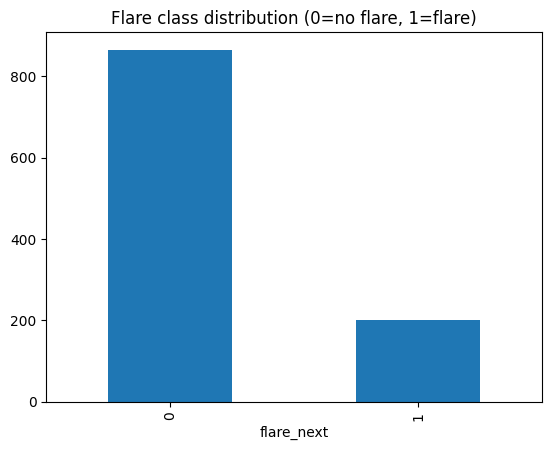

In [8]:
flare_df['flare_next'].value_counts().plot(kind='bar', title='Flare class distribution (0=no flare, 1=flare)');

In [9]:
flare_df.shape

(1066, 11)

In [10]:
print(flare_df.isnull().sum())
print(flare_df.isnull().any(axis=1).sum())

zurich_class                   0
spot_size                      0
spot_distribution              0
activity                       0
evolution                      0
prev_24h_flare_activity        0
historically_complex           0
became_historically_complex    0
area                           0
largest_spot_area              0
flare_next                     0
dtype: int64
0


In [11]:
input_cols = [
    'zurich_class',               # 1. Code for class (modified Zurich class)
    'spot_size',                  # 2. Code for largest spot size
    'spot_distribution',          # 3. Code for spot distribution
    'activity',                   # 4. Activity (1=reduced, 2=unchanged)
    'evolution',                  # 5. Evolution (1=decay, 2=no growth, 3=growth)
    'prev_24h_flare_activity',    # 6. Previous 24 hour flare activity code
    'historically_complex',       # 7. Historically complex (1=Yes, 2=No)
    'became_historically_complex',# 8. Did region become historically complex on this pass?
    'area',                       # 9. Area (1=small, 2=large)
    'largest_spot_area',          # 10. Area of the largest spot (1=<=5, 2=>5)
]

In [12]:
target_col = 'flare_next'

In [13]:
copy_df = flare_df.copy()

In [14]:
# Split exactly 1066 rows
train_flare_df = copy_df.iloc[:746]      # Rows 0 to 745 (746 rows)
val_flare_df = copy_df.iloc[746:906]   # Rows 746 to 905 (160 rows)
test_flare_df = copy_df.iloc[906:]      # Rows 906 to 1065 (160 rows)


In [20]:
X_train = train_flare_df[input_cols]
X_val = val_flare_df[input_cols]
X_test = test_flare_df[input_cols]

y_train = train_flare_df[[target_col]]
y_val = val_flare_df[[target_col]]
y_test = test_flare_df[[target_col]]

In [22]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
encoder = OneHotEncoder(sparse_output=False, drop=None)

In [34]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=str).columns.tolist()

In [31]:
len(numeric_cols) + len(categorical_cols) == len(input_cols)

True

In [35]:
encoder.fit(X_train[categorical_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_categ

In [37]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [43]:
X_train[encoded_cols] = encoder.transform(X_train[categorical_cols])
X_train_final = X_train[numeric_cols + encoded_cols]

In [44]:
X_val[encoded_cols] = encoder.transform(X_val[categorical_cols])
X_val_final = X_val[numeric_cols + encoded_cols]

In [45]:
X_test[encoded_cols] = encoder.transform(X_test[categorical_cols])
X_test_final = X_test[numeric_cols + encoded_cols]

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [101]:
modelA = DecisionTreeClassifier(random_state=42, class_weight='balanced')

In [102]:
modelA.fit(X_train_final, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [103]:
modelA.score(X_train_final, y_train)

0.8230563002680965

In [104]:
modelA.score(X_val_final, y_val)

0.79375

In [105]:
from sklearn.tree import plot_tree, export_text

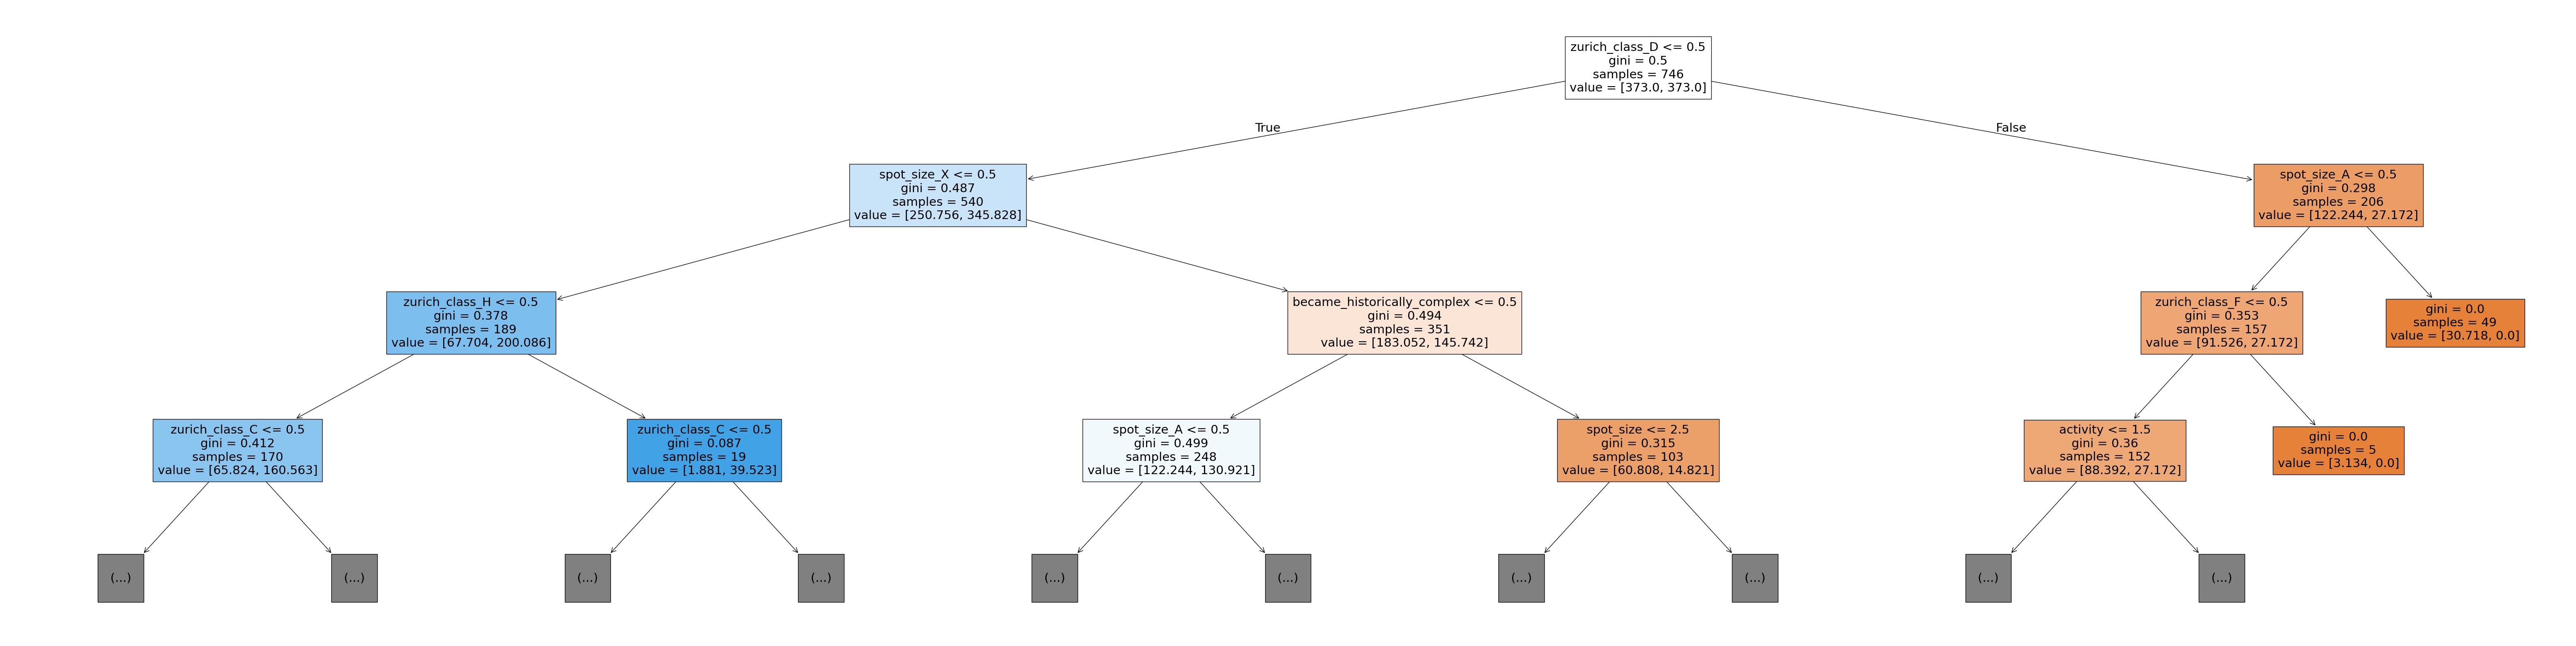

In [106]:
plt.figure(figsize=(80, 20))
plot_tree(modelA, feature_names=X_train.columns, filled=True, max_depth=3);

In [107]:
modelA.tree_.max_depth

15

In [108]:
importance_df = pd.DataFrame({

    'feature': X_train_final.columns,
    'Importance * 1000': modelA.feature_importances_*1000
   
}).sort_values('Importance * 1000', ascending=False)

In [109]:
importance_df

,feature,Importance * 1000
12,zurich_class_H,191.443640
21,spot_distribution_O,137.998563
1,evolution,118.029544
3,historically_complex,89.297967
16,spot_size_R,70.096198
7,zurich_class_B,66.705368
13,spot_size_A,42.533027
2,prev_24h_flare_activity,38.507478
0,activity,37.933902
8,zurich_class_C,33.033131


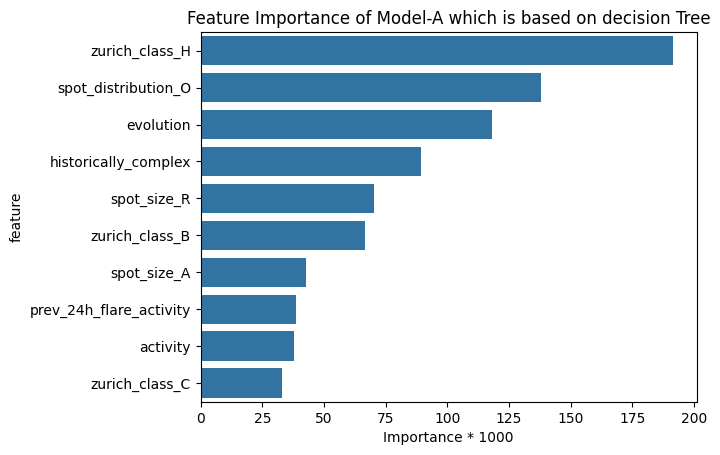

In [110]:
plt.title('Feature Importance of Model-A which is based on decision Tree');
sns.barplot(data=importance_df.head(10), y='feature', x='Importance * 1000');

In [111]:
from sklearn.metrics import classification_report
y_pred_train = modelA.predict(X_train_final)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.95      0.83      0.88       595
           1       0.54      0.81      0.65       151

    accuracy                           0.82       746
   macro avg       0.74      0.82      0.77       746
weighted avg       0.86      0.82      0.83       746



In [112]:
from sklearn.metrics import classification_report
y_pred_val = modelA.predict(X_val_final)
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88       137
           1       0.34      0.48      0.40        23

    accuracy                           0.79       160
   macro avg       0.62      0.66      0.64       160
weighted avg       0.83      0.79      0.81       160



In [113]:
from sklearn.metrics import recall_score

def max_depth_recall(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42, class_weight='balanced')
    model.fit(X_train_final, y_train)
    y_pred_train = model.predict(X_train_final)
    train_recall = recall_score(y_train, y_pred_train)
    y_pred_val = model.predict(X_val_final)
    val_recall = recall_score(y_val, y_pred_val)   # recall for class 1
    return {'max_depth': md, 'train_recall': train_recall*100, 'val_recall': val_recall*100}

In [114]:
%%time

error_df = pd.DataFrame([max_depth_recall(md) for md in range(1, 16)])

CPU times: total: 984 ms
Wall time: 1.07 s


In [115]:
error_df

,max_depth,train_recall,val_recall
0,1,92.715232,82.608696
1,2,53.642384,47.826087
2,3,88.741722,69.565217
3,4,82.119205,65.217391
4,5,82.119205,65.217391
5,6,79.470199,65.217391
6,7,81.456954,65.217391
7,8,81.456954,52.173913
8,9,79.470199,47.826087
9,10,82.119205,47.826087


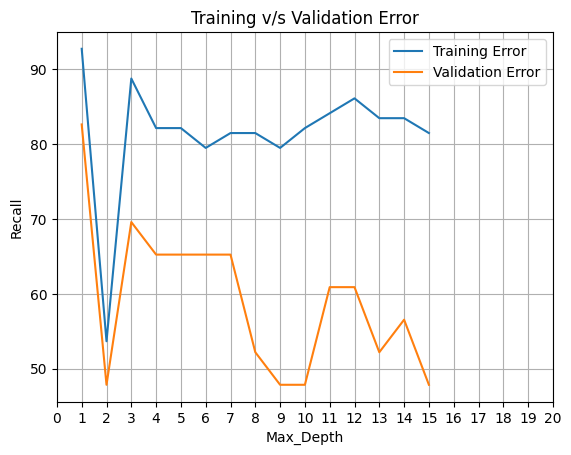

In [117]:
plt.grid(True)
plt.title('Training v/s Validation Error');
plt.plot(error_df['max_depth'], error_df['train_recall']);
plt.plot(error_df['max_depth'], error_df['val_recall']);
plt.legend(["Training Error", "Validation Error"]);
plt.ylabel('Recall')
plt.xticks(range(0, 21))
plt.xlabel('Max_Depth');

In [118]:
modelB = DecisionTreeClassifier(random_state=42, max_depth=1, class_weight='balanced')

In [119]:
modelB.fit(X_train_final, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [120]:
modelB.score(X_train_final, y_train)

0.44906166219839144

In [121]:
modelB.score(X_val_final, y_val)

0.525

In [124]:
from sklearn.metrics import classification_report
y_pred_train = modelB.predict(X_train_final)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.95      0.33      0.49       595
           1       0.26      0.93      0.41       151

    accuracy                           0.45       746
   macro avg       0.60      0.63      0.45       746
weighted avg       0.81      0.45      0.47       746



In [125]:
from sklearn.metrics import recall_score
y_pred_val = modelB.predict(X_val_final)
val_recall = recall_score(y_val, y_pred_val)
print(f"Validation recall for flares: {val_recall:.3f}")

Validation recall for flares: 0.826


In [126]:
from sklearn.metrics import recall_score
y_pred_test = modelB.predict(X_test_final)
test_recall = recall_score(y_test, y_pred_test)
print(f"Test recall for flares: {test_recall:.3f}")

Test recall for flares: 0.815


In [127]:
import joblib

# Save the final model
joblib.dump(modelB, 'solar_flare_tree.joblib')

# Save the fitted encoder (used to transform categorical features)
joblib.dump(encoder, 'onehot_encoder.joblib')

['onehot_encoder.joblib']